# Sistema RAG Interactivo con HuggingFace

## ¿Qué es RAG?

**RAG (Retrieval-Augmented Generation)** combina:
1. 🔍 Búsqueda de información relevante (Retrieval)
2. 🤖 Generación de respuestas con LLM (Generation)

### Pipeline:
```
Pregunta → Embedding → Búsqueda Vectorial → Contexto → LLM → Respuesta
```

### Ventajas:
- ✅ Respuestas basadas en documentos específicos
- ✅ Conocimiento actualizable sin reentrenar
- ✅ Respuestas fundamentadas (con fuentes)
- ✅ Reduce alucinaciones del LLM

## Instalación de Dependencias

In [ ]:
# Descomenta si necesitas instalar
# !pip install torch transformers sentence-transformers faiss-cpu numpy --quiet

import numpy as np
import torch
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import re
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")
print(f"🔧 Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Librerías importadas correctamente
🔧 Device: GPU


## Componente 1: Document Chunker

In [ ]:
class DocumentChunker:
    """Divide documentos en chunks manejables."""

    @staticmethod
    def chunk_by_paragraphs(text: str) -> List[str]:
        """Divide por párrafos."""
        return [p.strip() for p in text.split('\n\n') if p.strip()]

    @staticmethod
    def chunk_by_sentences(text: str, max_sentences: int = 3) -> List[str]:
        """Divide por frases."""
        sentences = re.split(r'[.!?]\s+', text)
        sentences = [s.strip() for s in sentences if s.strip()]

        chunks = []
        for i in range(0, len(sentences), max_sentences):
            chunk = '. '.join(sentences[i:i + max_sentences]) + '.'
            chunks.append(chunk)
        return chunks

    @staticmethod
    def chunk_by_words(text: str, chunk_size: int = 200, overlap: int = 50) -> List[str]:
        """Divide por palabras con overlap."""
        words = text.split()
        chunks = []

        for i in range(0, len(words), chunk_size - overlap):
            chunk = ' '.join(words[i:i + chunk_size])
            chunks.append(chunk)
            if i + chunk_size >= len(words):
                break
        return chunks

print("✅ DocumentChunker definido")

✅ DocumentChunker definido


## Componente 2: Vector Database

In [ ]:
class VectorDatabase:
    """Base de datos vectorial con FAISS."""

    def __init__(self, embedding_model_name: str = "all-MiniLM-L6-v2"):
        print(f"🔧 Inicializando Vector Database...")
        print(f"📦 Modelo: {embedding_model_name}")

        self.embedding_model = SentenceTransformer(embedding_model_name)
        self.dimension = self.embedding_model.get_sentence_embedding_dimension()
        self.index = faiss.IndexFlatL2(self.dimension)

        self.chunks = []
        self.metadata = []

        print(f"✅ Listo! Dimensión: {self.dimension}")

    def add_documents(self, chunks: List[str], metadata: List[Dict] = None):
        """Agrega documentos a la base de datos."""
        if not chunks:
            return

        print(f"📄 Agregando {len(chunks)} chunks...")

        # Generar embeddings
        embeddings = self.embedding_model.encode(
            chunks,
            show_progress_bar=True,
            convert_to_numpy=True
        )

        # Agregar a FAISS
        self.index.add(embeddings.astype('float32'))

        # Guardar chunks
        self.chunks.extend(chunks)

        if metadata:
            self.metadata.extend(metadata)
        else:
            self.metadata.extend([{"index": i} for i in range(len(chunks))])

        print(f"✅ Total en DB: {len(self.chunks)} chunks")

    def search(self, query: str, k: int = 3) -> List[Dict]:
        """Busca los k chunks más similares."""
        if len(self.chunks) == 0:
            return []

        # Embedding de la query
        query_embedding = self.embedding_model.encode(
            [query],
            convert_to_numpy=True
        ).astype('float32')

        # Buscar en FAISS
        distances, indices = self.index.search(query_embedding, min(k, len(self.chunks)))

        # Preparar resultados
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            results.append({
                'chunk': self.chunks[idx],
                'score': float(dist),
                'metadata': self.metadata[idx],
                'index': int(idx)
            })

        return results

print("✅ VectorDatabase definida")

✅ VectorDatabase definida


## Componente 3: LLM Generator

In [ ]:
class LLMGenerator:
    """Generador de respuestas con LLM."""

    def __init__(self, model_name: str = "google/flan-t5-base"):
        print(f"🤖 Inicializando LLM...")
        print(f"📦 Modelo: {model_name}")

        self.model_name = model_name
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name) # cpu
        self.model = self.model.to(self.device) # cuda

        print(f"✅ Listo! Usando: {self.device}")

    def generate(self, query: str, context: str, max_length: int = 200, temperature: float = 0.7) -> str:
        """Genera respuesta basada en contexto."""
        # Crear prompt
        prompt = f"""Answer the question based on the context below.

        Context: {context}

        Question: {query}

        Answer:"""

        # Tokenizar
        inputs = self.tokenizer(
            prompt,
            return_tensors="pt",
            max_length=1024,
            truncation=True
        ).to(self.device)

        # Generar
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_length=max_length,
                temperature=temperature,
                do_sample=True if temperature > 0 else False,
                top_p=0.9,
                num_return_sequences=1
            )

        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        return response

print("✅ LLMGenerator definido")

✅ LLMGenerator definido


## Sistema RAG Completo

In [ ]:
class RAGSystem:
    """Sistema RAG completo."""

    def __init__(self,
                 embedding_model: str = "all-MiniLM-L6-v2",
                 llm_model: str = "google/flan-t5-base",
                 chunk_method: str = "sentence"):

        print("\n" + "="*70)
        print("🚀 INICIALIZANDO SISTEMA RAG")
        print("="*70 + "\n")

        self.chunker = DocumentChunker()
        self.vector_db = VectorDatabase(embedding_model)
        self.generator = LLMGenerator(llm_model)
        self.chunk_method = chunk_method

        print("\n" + "="*70)
        print("✅ SISTEMA RAG LISTO")
        print("="*70 + "\n")

    def load_documents(self, documents: List[str], chunk_size: int = 3):
        """Carga y procesa documentos."""
        print(f"📚 Procesando {len(documents)} documento(s)...")

        all_chunks = []
        all_metadata = []

        for doc_idx, document in enumerate(documents):
            # Chunking
            if self.chunk_method == "paragraph":
                chunks = self.chunker.chunk_by_paragraphs(document)
            elif self.chunk_method == "sentence":
                chunks = self.chunker.chunk_by_sentences(document, max_sentences=chunk_size)
            else:
                chunks = [document]

            # Metadata
            metadata = [
                {'doc_id': doc_idx, 'chunk_id': i, 'length': len(chunk)}
                for i, chunk in enumerate(chunks)
            ]

            all_chunks.extend(chunks)
            all_metadata.extend(metadata)

        print(f"📝 Total chunks: {len(all_chunks)}")
        self.vector_db.add_documents(all_chunks, all_metadata)

    def query(self, question: str, k: int = 3, show_context: bool = False) -> Dict:
        """Procesa una pregunta con RAG."""
        # Búsqueda vectorial
        retrieved_docs = self.vector_db.search(question, k=k)

        if not retrieved_docs:
            return {
                'answer': "No tengo información para responder esa pregunta.",
                'sources': [],
                'context': ""
            }

        # Construir contexto
        context = "\n\n".join([doc['chunk'] for doc in retrieved_docs])

        if show_context:
            print("\n" + "="*70)
            print("📄 CONTEXTO RECUPERADO:")
            print("="*70)
            for i, doc in enumerate(retrieved_docs, 1):
                print(f"\n[Fuente {i}] (Score: {doc['score']:.4f})")
                print(f"{doc['chunk'][:200]}...")
            print("="*70 + "\n")

        # Generar respuesta
        answer = self.generator.generate(question, context)

        return {
            'answer': answer,
            'sources': retrieved_docs,
            'context': context,
            'num_sources': len(retrieved_docs)
        }

print("✅ RAGSystem definido")

✅ RAGSystem definido


## Documentos de Ejemplo

Vamos a cargar algunos documentos sobre IA para probar el sistema.

In [ ]:
# Documentos de ejemplo sobre IA
sample_documents = [
    """
    La Inteligencia Artificial (IA) es un campo de la informática que se enfoca en
    crear sistemas capaces de realizar tareas que normalmente requieren inteligencia
    humana. Esto incluye el aprendizaje, el razonamiento, la resolución de problemas,
    la percepción y el entendimiento del lenguaje.

    Los principales enfoques en IA incluyen el aprendizaje automático (Machine Learning),
    donde las máquinas aprenden de datos sin ser explícitamente programadas, y el
    aprendizaje profundo (Deep Learning), que usa redes neuronales artificiales con
    múltiples capas para aprender representaciones complejas de datos.
    """,

    """
    Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes
    cantidades de texto para entender y generar lenguaje humano. Estos modelos, como
    GPT, BERT y T5, han revolucionado el procesamiento del lenguaje natural.

    Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de
    atención para capturar relaciones entre palabras en el texto. Se entrenan con
    miles de millones de parámetros en datasets masivos de internet, libros y documentos.
    """,

    """
    La Generación Aumentada por Recuperación (RAG) es una técnica que combina la
    búsqueda de información con modelos de lenguaje. RAG primero busca documentos
    relevantes en una base de datos y luego usa esa información como contexto para
    que el LLM genere respuestas más precisas y fundamentadas.

    RAG es especialmente útil para aplicaciones que necesitan acceso a información
    actualizada o específica de un dominio, ya que permite actualizar la base de
    conocimientos sin reentrenar el modelo completo. Esto lo hace ideal para chatbots
    empresariales, asistentes de documentación y sistemas de preguntas y respuestas.
    """,

    """
    Las redes neuronales convolucionales (CNNs) son especialmente efectivas para el
    procesamiento de imágenes. Utilizan filtros convolucionales para detectar
    características locales como bordes, texturas y patrones. Las CNNs han logrado
    resultados sobresalientes en tareas de visión por computadora como clasificación
    de imágenes, detección de objetos y segmentación semántica.
    """,

    """
    El aprendizaje por refuerzo (Reinforcement Learning) es un tipo de aprendizaje
    automático donde un agente aprende a tomar decisiones mediante la interacción
    con un entorno. El agente recibe recompensas o penalizaciones por sus acciones
    y aprende a maximizar la recompensa acumulada a largo plazo. Esta técnica se ha
    utilizado exitosamente en juegos, robótica y sistemas de recomendación.
    """
]

print(f"✅ {len(sample_documents)} documentos de ejemplo preparados")

✅ 5 documentos de ejemplo preparados


## Inicializar Sistema RAG

### Configuración de Modelos:

**Embeddings:**
- `all-MiniLM-L6-v2` - Rápido, 384 dim ⭐
- `all-mpnet-base-v2` - Mejor calidad, 768 dim

**LLM:**
- `google/flan-t5-small` - Muy rápido
- `google/flan-t5-base` - Recomendado ⭐
- `google/flan-t5-large` - Mejor calidad

In [ ]:
# Inicializar sistema RAG
rag = RAGSystem(
    embedding_model="all-MiniLM-L6-v2",
    llm_model="google/flan-t5-base",
    chunk_method="paragraph"
)


🚀 INICIALIZANDO SISTEMA RAG

🔧 Inicializando Vector Database...
📦 Modelo: all-MiniLM-L6-v2
✅ Listo! Dimensión: 384
🤖 Inicializando LLM...
📦 Modelo: google/flan-t5-base


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Listo! Usando: cuda

✅ SISTEMA RAG LISTO



## Cargar Documentos

In [ ]:
# Cargar documentos en el sistema
rag.load_documents(sample_documents)

📚 Procesando 5 documento(s)...
📝 Total chunks: 8
📄 Agregando 8 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Total en DB: 8 chunks


## Modo de Preguntas por Celdas

Si prefieres hacer una pregunta por celda (sin bucle while):

In [ ]:
# Pregunta 1
question = "What is machine learning?"

result = rag.query(question, k=2, show_context=True)

print(f"\n❓ Pregunta: {question}")
print(f"\n🤖 Respuesta: {result['answer']}")


📄 CONTEXTO RECUPERADO:

[Fuente 1] (Score: 0.9400)
Los principales enfoques en IA incluyen el aprendizaje automático (Machine Learning), 
    donde las máquinas aprenden de datos sin ser explícitamente programadas, y el 
    aprendizaje profundo (Deep...

[Fuente 2] (Score: 1.3495)
La Inteligencia Artificial (IA) es un campo de la informática que se enfoca en 
    crear sistemas capaces de realizar tareas que normalmente requieren inteligencia 
    humana. Esto incluye el aprend...


❓ Pregunta: What is machine learning?

🤖 Respuesta: automático


In [ ]:
# Pregunta 2
question = "Explain RAG systems"

result = rag.query(question, k=3, show_context=True)

print(f"\n❓ Pregunta: {question}")
print(f"\n🤖 Respuesta: {result['answer']}")


📄 CONTEXTO RECUPERADO:

[Fuente 1] (Score: 1.1378)
La Generación Aumentada por Recuperación (RAG) es una técnica que combina la 
    búsqueda de información con modelos de lenguaje. RAG primero busca documentos 
    relevantes en una base de datos y l...

[Fuente 2] (Score: 1.8318)
Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes 
    cantidades de texto para entender y generar lenguaje humano. Estos modelos, como 
    GPT, BERT y T5, han revolucion...

[Fuente 3] (Score: 1.8749)
Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para capturar relaciones entre palabras en el texto. Se entrenan con 
    miles de millones de parámetros...


❓ Pregunta: Explain RAG systems

🤖 Respuesta: la bsqueda de información con modelos de lenguaje


In [ ]:
# Pregunta 3 - Con input interactivo
question = input("❓ Tu pregunta: ")

result = rag.query(question, k=2, show_context=True)

print(f"\n🤖 Respuesta: {result['answer']}")
print(f"\n📊 Fuentes usadas: {result['num_sources']}")

❓ Tu pregunta:  What is LLMs?



📄 CONTEXTO RECUPERADO:

[Fuente 1] (Score: 1.2210)
Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes 
    cantidades de texto para entender y generar lenguaje humano. Estos modelos, como 
    GPT, BERT y T5, han revolucion...

[Fuente 2] (Score: 1.4487)
Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para capturar relaciones entre palabras en el texto. Se entrenan con 
    miles de millones de parámetros...


🤖 Respuesta: Los Modelos de Lenguaje Grande

📊 Fuentes usadas: 2


## Ver Contexto y Fuentes

In [ ]:
# Hacer pregunta y examinar en detalle
question = "What are LLMs?"

result = rag.query(question, k=3, show_context=False)

print(f"❓ Pregunta: {question}")
print(f"\n🤖 Respuesta: {result['answer']}")
print(f"\n" + "="*70)
print("📚 FUENTES UTILIZADAS:")
print("="*70)

for i, source in enumerate(result['sources'], 1):
    print(f"\n[Fuente {i}]")
    print(f"Score/Distance/Confidence: {source['score']:.4f}")
    print(f"Texto: {source['chunk'][:150]}...")
    print(f"Metadata: {source['metadata']}")

❓ Pregunta: What are LLMs?

🤖 Respuesta: models of IA

📚 FUENTES UTILIZADAS:

[Fuente 1]
Score/Distance/Confidence: 1.2259
Texto: Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes 
    cantidades de texto para entender y generar lenguaje humano. Estos...
Metadata: {'doc_id': 1, 'chunk_id': 0, 'length': 242}

[Fuente 2]
Score/Distance/Confidence: 1.4471
Texto: Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para capturar relaciones entre palabras en el texto. Se...
Metadata: {'doc_id': 1, 'chunk_id': 1, 'length': 254}

[Fuente 3]
Score/Distance/Confidence: 1.6307
Texto: La Generación Aumentada por Recuperación (RAG) es una técnica que combina la 
    búsqueda de información con modelos de lenguaje. RAG primero busca d...
Metadata: {'doc_id': 2, 'chunk_id': 0, 'length': 307}


## Cargar Tus Propios Documentos

Puedes cargar tus propios documentos desde archivos:

In [ ]:
# Ejemplo: Cargar desde archivos de texto
# my_documents = []
#
# # Leer archivos
# with open('documento1.txt', 'r', encoding='utf-8') as f:
#     my_documents.append(f.read())
#
# with open('documento2.txt', 'r', encoding='utf-8') as f:
#     my_documents.append(f.read())
#
# # Crear nuevo sistema RAG
# my_rag = RAGSystem()
# my_rag.load_documents(my_documents)
#
# # Hacer preguntas
# result = my_rag.query("Tu pregunta sobre tus documentos")
# print(result['answer'])

print("Descomenta el código de arriba para usar tus propios documentos")

Descomenta el código de arriba para usar tus propios documentos


## Experimentar con Parámetros

In [ ]:
# Comparar diferentes valores de K (número de chunks recuperados)
question = "What is deep learning?"

print("Comparando diferentes valores de K:\n")

for k in [1, 2, 3, 5]:
    result = rag.query(question, k=k, show_context=False)
    print(f"\nK={k}:")
    print(f"Respuesta: {result['answer']}")
    print(f"Fuentes usadas: {result['num_sources']}")
    print("-" * 70)

Comparando diferentes valores de K:


K=1:
Respuesta: deep learning
Fuentes usadas: 1
----------------------------------------------------------------------

K=2:
Respuesta: deep learning
Fuentes usadas: 2
----------------------------------------------------------------------

K=3:
Respuesta: el aprendizaje profundo
Fuentes usadas: 3
----------------------------------------------------------------------

K=5:
Respuesta: deep learning
Fuentes usadas: 5
----------------------------------------------------------------------


In [ ]:
# Comparar diferentes métodos de chunking
print("Comparando métodos de chunking:\n")

for method in ['paragraph', 'sentence']:
    print(f"\n{'='*70}")
    print(f"Método: {method}")
    print(f"{'='*70}")

    test_rag = RAGSystem(
        embedding_model="all-MiniLM-L6-v2",
        llm_model="google/flan-t5-base",
        chunk_method=method
    )

    test_rag.load_documents([sample_documents[0]])  # Solo primer doc para rapidez

    result = test_rag.query("What is AI?", k=2, show_context=False)
    print(f"\nRespuesta: {result['answer']}")

Comparando métodos de chunking:


Método: paragraph

🚀 INICIALIZANDO SISTEMA RAG

🔧 Inicializando Vector Database...
📦 Modelo: all-MiniLM-L6-v2
✅ Listo! Dimensión: 384
🤖 Inicializando LLM...
📦 Modelo: google/flan-t5-base
✅ Listo! Usando: cuda

✅ SISTEMA RAG LISTO

📚 Procesando 1 documento(s)...
📝 Total chunks: 2
📄 Agregando 2 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Total en DB: 2 chunks

Respuesta: A field of la informática

Método: sentence

🚀 INICIALIZANDO SISTEMA RAG

🔧 Inicializando Vector Database...
📦 Modelo: all-MiniLM-L6-v2
✅ Listo! Dimensión: 384
🤖 Inicializando LLM...
📦 Modelo: google/flan-t5-base
✅ Listo! Usando: cuda

✅ SISTEMA RAG LISTO

📚 Procesando 1 documento(s)...
📝 Total chunks: 1
📄 Agregando 1 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Total en DB: 1 chunks

Respuesta: field of la informática


## Análisis de Similitud

Veamos qué tan similares son los chunks recuperados:


What is artificial intelligence?
Scores: ['0.8740', '1.1052', '1.2450']

Explain machine learning
Scores: ['0.9692', '1.3320', '1.3966']

What are neural networks?
Scores: ['0.9348', '1.1893', '1.4167']

How does RAG work?
Scores: ['1.1900', '1.9168', '1.9316']


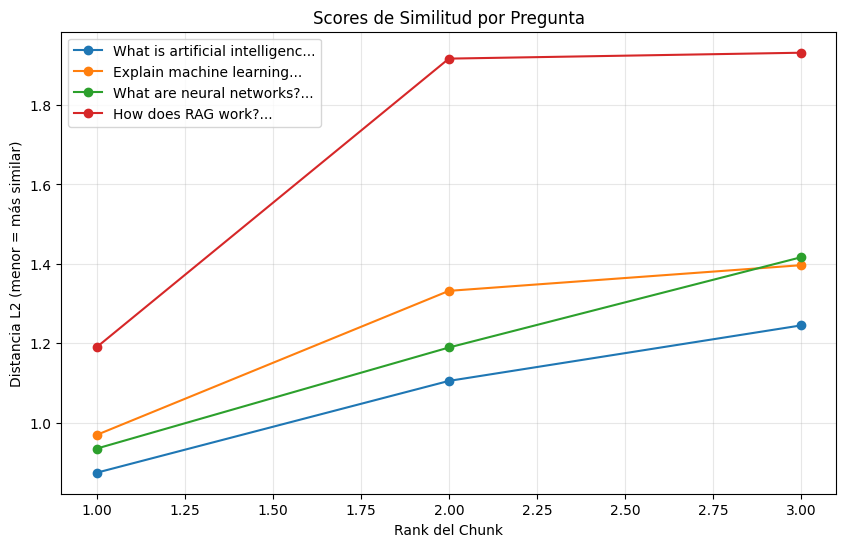

In [ ]:
import matplotlib.pyplot as plt

# Hacer varias preguntas y ver scores
questions = [
    "What is artificial intelligence?",
    "Explain machine learning",
    "What are neural networks?",
    "How does RAG work?"
]

all_scores = []

for q in questions:
    result = rag.query(q, k=3, show_context=False)
    scores = [s['score'] for s in result['sources']]
    all_scores.append(scores)
    print(f"\n{q}")
    print(f"Scores: {[f'{s:.4f}' for s in scores]}")

# Visualizar scores
plt.figure(figsize=(10, 6))
for i, (q, scores) in enumerate(zip(questions, all_scores)):
    plt.plot(range(1, len(scores)+1), scores, marker='o', label=q[:30]+'...')

plt.xlabel('Rank del Chunk')
plt.ylabel('Distancia L2 (menor = más similar)')
plt.title('Scores de Similitud por Pregunta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Modo Interactivo - Hacer Preguntas

### Comandos especiales:
- `salir` o `exit` - Terminar
- Cualquier pregunta sobre IA, ML, LLMs, RAG, etc.

**¡Ejecuta esta celda y empieza a preguntar!**

In [ ]:
print("🤖 Sistema RAG listo! Haz preguntas sobre IA.\n")
print("💡 Temas: Inteligencia Artificial, Machine Learning, LLMs, RAG, CNNs, RL")
print("💡 Comando: 'salir' para terminar\n")
print("="*70)

while True:
    try:
        # Obtener pregunta
        question = input("\n❓ Tu pregunta: ").strip()

        # Comando de salida
        if question.lower() in ['salir', 'exit', 'quit']:
            print("\n👋 ¡Hasta luego!")
            break

        if not question:
            continue

        # Procesar pregunta
        print("\n🔍 Buscando información relevante...")
        result = rag.query(
            question,
            k=2,
            show_context=True
        )

        # Mostrar respuesta
        print("\n" + "="*70)
        print("🤖 RESPUESTA:")
        print("="*70)
        print(result['answer'])
        print("="*70)
        print(f"\n📚 Basado en {result['num_sources']} fuente(s)")

    except KeyboardInterrupt:
        print("\n\n👋 ¡Hasta luego!")
        break
    except Exception as e:
        print(f"❌ Error: {e}")
        continue

🤖 Sistema RAG listo! Haz preguntas sobre IA.

💡 Temas: Inteligencia Artificial, Machine Learning, LLMs, RAG, CNNs, RL
💡 Comando: 'salir' para terminar




❓ Tu pregunta:  dime acerca de un RAG



🔍 Buscando información relevante...

📄 CONTEXTO RECUPERADO:

[Fuente 1] (Score: 1.2861)
La Generación Aumentada por Recuperación (RAG) es una técnica que combina la 
    búsqueda de información con modelos de lenguaje. RAG primero busca documentos 
    relevantes en una base de datos y l...

[Fuente 2] (Score: 1.5420)
Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para capturar relaciones entre palabras en el texto. Se entrenan con 
    miles de millones de parámetros...


🤖 RESPUESTA:
A).

📚 Basado en 2 fuente(s)


### Tips para mejores resultados:

1. **Calidad de documentos**:
   - Usa documentos bien estructurados
   - Limpia el texto (elimina ruido)
   - Divide por temas coherentes

2. **Chunking**:
   - Párrafos → Documentos estructurados ⭐
   - Frases → Texto continuo
   - Palabras → Control preciso del tamaño

3. **Parámetro K**:
   - K=2-3 → Respuestas concisas
   - K=5-7 → Más contexto, respuestas completas
   - K alto → Riesgo de ruido

4. **Modelos**:
   - `all-MiniLM-L6-v2` → Rápido, bueno para prototipado
   - `flan-t5-base` → Balance calidad/velocidad
   - `flan-t5-large` → Mejor calidad (si tienes GPU)

### Limitaciones:
- La calidad depende de los documentos cargados
- El LLM puede "alucinar" si el contexto no es suficiente
- Chunks muy grandes pueden perder precisión
- Chunks muy pequeños pierden contexto

### Extensiones posibles:
- Implementar filtrado por metadata
- Usar ChromaDB en lugar de FAISS
- Agregar caché de embeddings
- Implementar búsqueda híbrida (vectorial + BM25)
- Implementar búsqueda híbrida (vectorial + BM25)